<div style="text-align:center; padding:20px 0">
<img src="https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/media/logo_dataprojectlab.png" width="220"/>
</div>

# DataProjectLab - Projet Sante
## Prevision de la demande en medicaments
### Notebook 1 - Contexte, Brief Metier & Decouverte des Donnees
### VERSION CORRIGEE - Mode formateur

---

> **Comment lire ce notebook :**
> Chaque etape est precedee d'une cellule qui explique le POURQUOI avant le COMMENT.
> Les blocs `METHODE` expliquent les choix techniques et les bonnes pratiques.
> Les blocs `INTERPRETATION` lisent les resultats comme le ferait un analyste lors d'une restitution.
> Les blocs `CLINIQUE` font le lien entre le chiffre et la realite medicale.

---

| Info | Detail |
|---|---|
| **Niveau** | Avance |
| **Outils** | Python |
| **Duree estimee** | 1h a 2h |
| **Competences** | Business understanding hospitalier - Lecture de donnees - Cadrage analytique - Premiers KPIs |

---

### Plan du notebook

```
1. La mission et le contexte clinique
2. Le brief du Dr. Konan
3. Les 6 fichiers du projet (dictionnaire des donnees)
4. Tache 0 - Reflexion strategique avant de coder
5. Chargement des 6 datasets
6. Exploration structuree (5 questions)
7. Visualisation : etat des stocks critiques
8. Synthese et transition vers NB2
```

---

# 1. La mission et le contexte clinique

Tu viens d'etre recrute(e) comme **Data Analyst junior** a la pharmacie centrale de l'**Hopital General Universitaire de Cocody** (Abidjan, Cote d'Ivoire).

Ton responsable, le Dr. Konan (Pharmacien Chef), t'a convoque(e) pour ta premiere mission reelle.

> **CLINIQUE - Ce projet est different de tous les projets e-commerce ou support.**
>
> En e-commerce, une erreur de prevision = des invendus ou une rupture de stock.
> A l'hopital, une erreur de prevision = un patient sans traitement.
>
> La rupture d'insuline que mentionne le Dr. Konan n'est pas un inconfort.
> Un patient diabetique de type 1 sans insuline entre en acidocetose en 24 a 48h.
> C'est une urgence vitale.
>
> Cette difference de contexte change radicalement la facon de poser les problemes :
> - En e-commerce : optimiser la marge
> - A l'hopital : garantir la disponibilite des medicaments critiques
>   et minimiser le gaspillage (85 000 euros de medicaments perimant)
>
> **Regle fondamentale de ce projet :**
> La precision des previsions n'est pas evaluee sur le MAPE global.
> Elle est evaluee sur le MAPE des medicaments critiques specifiquement.
> Un MAPE de 30% sur un antibiotique courant est acceptable.
> Un MAPE de 30% sur l'insuline ne l'est pas.

---

# 2. Le brief du Dr. Konan

> *"Depuis le debut de l'annee, nous avons connu **7 ruptures de stock critiques**.
> La derniere rupture d'insuline a contraint notre service de diabetologie a reporter
> des traitements pendant 4 jours. En parallele, notre audit revele
> **85 000 euros de medicaments surtoques** dont la date de peremption approche.*
>
> *J'ai besoin d'un **systeme de prevision** pour savoir combien commander, pour quel
> medicament et a quelle frequence. Et d'un **dashboard Power BI** presentable
> a la direction chaque semaine."*

- Dr. Konan, Pharmacien Chef, HGU Cocody

> **METHODE - Decrypter le brief du Dr. Konan.**
>
> Le brief contient deux problemes opposes dans la meme pharmacie :
>
> **Probleme 1 : Ruptures (sous-stock)**
> 7 ruptures critiques. La rupture d'insuline = traitement reporte 4 jours.
> On manque de certains medicaments au bon moment.
>
> **Probleme 2 : Surstockage (sur-stock)**
> 85 000 euros de medicaments dont la peremption approche.
> On a trop de certains medicaments au mauvais moment.
>
> Ces deux problemes coexistent car la pharmacie n'a pas de systeme de prevision.
> Elle commande soit trop tot (surstockage), soit trop tard (rupture).
>
> **La solution que ce projet apporte :**
> Un modele de prevision qui dit, pour chaque medicament :
> 'Dans les 4 prochaines semaines, vous consommerez X unites.
>  Commandez Y unites maintenant pour avoir le stock de securite Z.'
>
> **Les 5 questions business a resoudre :**
> 1. Quels medicaments et services consomment le plus ? Saisonnalites ?
> 2. Quand et sur quels medicaments les ruptures se produisent-elles ?
> 3. Quels fournisseurs sont les plus fiables ?
> 4. Peut-on predire la consommation des 4 prochaines semaines ?
> 5. Quel stock de securite recommander par medicament critique ?

---

# 3. Les 6 fichiers du projet

> **METHODE - Lire le dictionnaire avant de toucher au code.**
>
> C'est encore plus critique dans un contexte hospitalier que dans un projet commercial.
> Les colonnes comme `medicament_critique`, `stock_securite` et `impact_clinique`
> ont des implications directes sur les decisions cliniques.
> Mal interpreter ces colonnes peut conduire a des recommandations dangereuses.

**Periode couverte :** Janvier 2022 -> Juin 2024 (30 mois)

## `medicaments.csv` (25 lignes)
Referentiel de tous les medicaments geres par la pharmacie.

| Colonne | Type | Description | Note analytique |
|---|---|---|---|
| `id_medicament` | string | Identifiant unique (ex: MED001) | Cle primaire |
| `nom` | string | Denomination commune internationale | Utiliser cette denomination, pas la marque |
| `categorie` | string | Classe therapeutique | Axe d'agregation (antibiotiques, analgesiques...) |
| `forme` | string | Forme galenique | Injectable = stock plus fragile (chaine du froid) |
| `stock_actuel` | int | Stock disponible en unites | Valeur a la date d'extraction |
| `prix_unitaire_euro` | float | Prix d'achat unitaire | Pour calculer l'impact financier des ruptures |
| `stock_securite` | int | Seuil minimum a ne jamais franchir | **Colonne cle** : franchir = rupture imminente |
| `stock_max` | int | Seuil maximum de stockage | Franchir = surstockage / risque de peremption |
| `medicament_critique` | bool | True si rupture = risque clinique eleve | **Colonne la plus importante du projet** |

> **CLINIQUE - `medicament_critique = True` : ce que ca signifie vraiment.**
>
> Ce flag ne signifie pas 'medicament cher' ou 'medicament tres consomme'.
> Il signifie : si ce medicament manque, un patient est en danger de mort
> ou son traitement est severely compromis dans les 24-48h.
> Tous les modeles de prevision du Notebook 4 traiteront ces medicaments
> avec une exigence de precision superieure.

## `consommations.csv` (~53 000 lignes)
Le coeur du projet. Chaque ligne = une consommation journaliere d'un medicament dans un service.

| Colonne | Type | Description | Note analytique |
|---|---|---|
| `id_consommation` | string | Identifiant unique | Cle primaire |
| `date` | date | Date de consommation (YYYY-MM-DD) | **parse_dates obligatoire** |
| `id_medicament` | FK | Reference vers medicaments.csv | FK cle |
| `id_service` | FK | Reference vers services.csv | Permet l'analyse par service hospitalier |
| `quantite_consommee` | int | Unites consommees ce jour | **Variable cible** du modele ML |
| `cout_euro` | float | Cout total de la consommation | `quantite_consommee * prix_unitaire` |

> **METHODE - La granularite : 1 ligne = 1 medicament x 1 service x 1 jour.**
>
> Avec 25 medicaments, 10 services et ~900 jours (30 mois) :
> theorique max = 25 x 10 x 900 = 225 000 lignes.
> Les donnees reelles (~53 000 lignes) montrent que tous les medicaments
> ne sont pas consommes dans tous les services chaque jour.
> C'est un signal important : certains medicaments ont une consommation
> sporadique et non lineaire, ce qui complique la prevision.

## `commandes_fournisseurs.csv` (~964 lignes)

| Colonne | Type | Description | Note analytique |
|---|---|---|
| `date_commande` | date | Date de passation de commande | **parse_dates obligatoire** |
| `id_fournisseur` | FK | Fournisseur choisi | Cle pour l'analyse de fiabilite |
| `statut` | string | Livree / En cours / Annulee | Filtrer sur 'Livree' pour les KPIs de delai |
| `date_livraison_reelle` | date | Date effective de livraison | **parse_dates obligatoire** |
| `retard_jours` | int | Jours de retard (0 = a temps) | **Colonne cle** : impact sur stock de securite |

> **CLINIQUE - `retard_jours` et le stock de securite.**
>
> Si EuroPharma a un delai contractuel de 21 jours mais prend en realite
> 27 jours en moyenne (retard de 6 jours), le stock de securite pour
> les medicaments fournis par EuroPharma doit couvrir 27 jours et non 21.
> La formule du stock de securite sera calculee en Notebook 4 avec ces donnees reelles.

## Fichiers complementaires
- **`services.csv`** (10 lignes) - Services hospitaliers avec capacite en lits
- **`fournisseurs.csv`** (5 lignes) - Fournisseurs avec delais et taux de service declares
- **`ruptures_stock.csv`** (85 lignes) - Evenements de rupture avec impact clinique et patients affectes

---

# 4. Tache 0 - Reflexion strategique avant de coder

> **METHODE - Reflechir au probleme metier avant d'ouvrir un fichier.**
>
> Un analyste junior ouvre directement Python et commence a coder.
> Un analyste experimente passe 30 minutes a comprendre le contexte
> avant d'ecrire la premiere ligne de code.
>
> Cette tache 0 simule ce travail de reflexion. Les reponses ici sont des
> **hypotheses de travail** qu'on testera et affinera avec les donnees.
> Si les donnees contredisent une hypothese, c'est souvent l'insight le plus riche.

### Question 1 - Les 2 medicaments les plus risques en cas de rupture

**Raisonnement :**
On identifie les medicaments pour lesquels l'absence d'alternative therapeutique
immediate met la vie du patient en danger.

**Insuline Glargine (MED008) :**
Un patient diabetique de type 1 sans insuline entre en acidocetose en 24-48h.
Risque vital immediat. Aucune alternative therapeutique en urgence.

**Morphine (MED012) :**
Seul analgesique de palier 3 pour les douleurs severes en oncologie et post-chirurgie.
Pas de substitut efficace immediat. L'absence force le medecin a gerer
une douleur severe avec des outils insuffisants.

**Heparine (MED014) :**
Anticoagulant critique en reanimation et post-chirurgie.
L'arret peut provoquer une thrombose fatale en quelques heures.

**Erythropoietine (MED023) :**
Couteuse et difficile a sourcer rapidement, utilisee en oncologie.

> **CLINIQUE - La logique de priorisation.**
>
> Ce n'est pas 'le medicament le plus consomme' ni 'le plus cher'.
> C'est : si ce medicament manque 24 heures, quel est le risque clinique immediat ?
> Cette logique va directement influencer notre score de criticite en Notebook 2
> et les marges d'erreur acceptables pour chaque medicament en Notebook 4.

---

### Question 2 - Modele de prevision adapte

**Reponse : Serie temporelle avec saisonnalite**
(SARIMA, Prophet ou Random Forest avec features temporelles)

> **METHODE - Pourquoi les series temporelles et pas la regression lineaire ?**
>
> La consommation de medicaments suit des patterns repetables :
> - Saisonnalite hebdomadaire : moins de consommation le weekend
>   (moins d'admissions programmees)
> - Saisonnalite annuelle : antibiotiques en hausse en hiver
>   (infections respiratoires), antipaludeens en hausse saison humide
>
> Une regression lineaire suppose une tendance monotone.
> Elle ne capture pas ces cycles. Un modele de series temporelles les capture.
>
> **Le choix entre SARIMA, Prophet et Random Forest sera fait en Notebook 4**
> apres validation croisee temporelle (TimeSeriesSplit) sur les donnees reelles.

---

### Question 3 - Donnees supplementaires ideales

Trois types de donnees absentes qui amelioreraient les previsions :

**1. Nombre de patients admis par service** :
La consommation est mecaniquement correlee a l'occupation des lits.
Un service de cardiologie a 110% de capacite consomme plus de medicaments
cardio qu'a 70%. Sans cette donnee, le modele a un angle mort.

**2. Donnees epidemiologiques locales** :
Le calendrier des maladies en Cote d'Ivoire ne suit pas le calendrier europeen.
Le paludisme a des pics saisonniers specifiques qui impactent la consommation
d'antipaludeens. Ces donnees ne sont pas dans nos CSV.

**3. Ordonnances nominatives** :
Savoir quel medicament est prescrit pour quel patient permettrait des previsions
a granularite individuelle - bien plus precisees que les agregats journaliers.

> **METHODE - Ces limites doivent etre documentees dans le rapport final.**
>
> Un analyste honnete documente ce qu'il ne sait pas, pas seulement ce qu'il sait.
> Ces donnees manquantes doivent apparaitre dans la section 'Limites du modele'
> de la restitution finale au Dr. Konan. Un modele avec des limites documentees
> est plus credible qu'un modele qui ne reconnait aucune limite.

---

# 5. Configuration et chargement des donnees

## 5.1 - Configuration de l'environnement

> **METHODE - La palette de couleurs semantique : un choix delibere.**
>
> Les couleurs ne sont pas des preferences esthetiques - elles encodent du sens :
> - Rouge `#E24B4A` : danger, rupture, situation critique
> - Orange `#BA7517` : alerte, seuil approche, vigilance
> - Vert `#1D9E75` : situation normale, stock OK
> - Bleu `#185FA5` : information principale, neutre
>
> Cette palette sera identique dans les notebooks 2, 3, 4 et dans le dashboard Power BI.
> La coherence visuelle est une bonne pratique professionnelle :
> quand le Dr. Konan voit du rouge, il sait que c'est une alerte
> sans avoir besoin de lire le titre du graphique.
>
> **`pd.set_option('display.float_format', '{:.2f}'.format)` :**
> Sans cette option, `85000.73000000001` s'affiche au lieu de `85000.73`.
> En contexte hospitalier ou chaque euro compte, ce formatage
> est essentiel pour des presentations credibles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.2f}".format)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F8F8F6",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "font.size":        11
})

# Palette semantique : rouge=danger, orange=alerte, vert=OK, bleu=neutre
COLORS = {
    "primary":   "#185FA5",
    "secondary": "#1D9E75",
    "warning":   "#BA7517",
    "danger":    "#E24B4A",
    "neutral":   "#888780",
    "light":     "#D3D1C7"
}

print("Imports et configuration OK")

Imports et configuration OK


## 5.2 - Chargement des 6 datasets

> **METHODE - `parse_dates` est obligatoire sur toutes les colonnes de dates.**
>
> Sans `parse_dates=['date']`, pandas charge la colonne comme un `object` (string).
> Consequences directes sur ce projet :
>
> `df_conso['date'].dt.month` -> `AttributeError` (impossible d'extraire le mois)
>
> `df_conso.sort_values('date')` -> tri alphabetique.
> '2022-12-01' vient apres '2022-09-15' en tri alphabetique mais pas en tri chronologique.
> Les graphiques d'evolution temporelle seraient completement faux.
>
> `df_conso['date'].max() - df_conso['date'].min()` -> `TypeError`.
> Impossible de calculer la duree de la periode.
>
> **Regle absolue sur tout projet avec des dates :**
> `parse_dates` au `read_csv`, jamais apres. Jamais.
>
> **Pourquoi `parse_dates=['date']` et non `parse_dates=True` ?**
> `parse_dates=True` essaie de parser toutes les colonnes et peut etre tres lent
> sur de grands datasets. `parse_dates=['date']` ne parse que la colonne specifiee.
> Toujours specifier les colonnes explicitement.

In [2]:
BASE_URL = "https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/projets/pharmacy_analytics/data/"

df_med   = pd.read_csv(f"{BASE_URL}medicaments.csv")
df_srv   = pd.read_csv(f"{BASE_URL}services.csv")
df_frn   = pd.read_csv(f"{BASE_URL}fournisseurs.csv")
df_conso = pd.read_csv(f"{BASE_URL}consommations.csv",            parse_dates=["date"])
df_cmd   = pd.read_csv(f"{BASE_URL}commandes_fournisseurs.csv",
                        parse_dates=["date_commande","date_livraison_reelle"])
df_rup   = pd.read_csv(f"{BASE_URL}ruptures_stock.csv",
                        parse_dates=["date_debut","date_fin"])

print("=" * 55)
print(f"{'DATASET':<30} {'LIGNES':>8} {'COLONNES':>10}")
print("=" * 55)
for name, df in [("medicaments",df_med), ("services",df_srv),
                  ("fournisseurs",df_frn), ("consommations",df_conso),
                  ("commandes_fournisseurs",df_cmd), ("ruptures_stock",df_rup)]:
    print(f"{name:<30} {len(df):>8,} {len(df.columns):>10}")
print("=" * 55)

DATASET                          LIGNES   COLONNES
medicaments                          25          9
services                             10          4
fournisseurs                          5          7
consommations                    53,808          6
commandes_fournisseurs              964          9
ruptures_stock                       85          7


### INTERPRETATION - Lecture du tableau de dimensions

> **`consommations.csv` : ~53 000 lignes sur 30 mois.**
> C'est la colonne vertebrale du projet. Cette granularite (medicament x service x jour)
> est suffisante pour detecter des patterns hebdomadaires et saisonniers.
> 53 000 lignes / (25 medicaments x 10 services) = ~212 jours de consommation
> par combinaison en moyenne. Pas tous les medicaments sont consommes chaque jour.
>
> **`commandes_fournisseurs.csv` : ~964 lignes sur 30 mois.**
> ~32 commandes par mois en moyenne. Pour 25 medicaments et 5 fournisseurs,
> ca signifie que chaque medicament est commande environ 1 a 2 fois par mois.
> C'est faible - signal que les commandes sont groupees, pas individuelles.
>
> **`ruptures_stock.csv` : 85 lignes.**
> 85 evenements de rupture sur 30 mois = ~3 ruptures par mois en moyenne.
> Ramene aux 7 ruptures critiques mentionnees par le Dr. Konan (pour cette annee),
> on comprend que toutes les ruptures ne sont pas 'critiques'.
> La distinction entre rupture standard et rupture critique sera analysee en NB3.

---

# 6. Exploration structuree - Reponses aux 5 questions

> **METHODE - Repondre aux questions metier avec Python, pas SQL.**
>
> A ce stade du projet, on n'a pas encore de base SQL configuree.
> Python + pandas permet de repondre a toutes ces questions directement
> sur les CSV. C'est l'exploration initiale.
>
> Le Notebook 2 passera ensuite a DuckDB/SQL pour les analyses plus complexes
> (window functions, CTEs, jointures multi-tables).

In [3]:
# Question 1 : Periode exacte des consommations
print("-- 1. PERIODE DES DONNEES ------------------------------------------")
debut  = df_conso["date"].min()
fin    = df_conso["date"].max()
duree  = (fin - debut).days
print(f"   Debut  : {debut.strftime('%d/%m/%Y')}")
print(f"   Fin    : {fin.strftime('%d/%m/%Y')}")
print(f"   Duree  : {duree} jours ({round(duree/30.4, 1)} mois)")

# Question 2 : Medicaments critiques
print("\n-- 2. MEDICAMENTS CRITIQUES ----------------------------------------")
critiques = df_med[df_med["medicament_critique"] == True]
print(f"   Nombre : {len(critiques)} medicaments critiques sur {len(df_med)}")
print("   Liste  :")
for _, row in critiques.iterrows():
    marge = row["stock_actuel"] - row["stock_securite"]
    statut = "CRITIQUE" if marge <= 0 else ("ALERTE" if marge <= 5 else "OK")
    print(f"   -> {row['id_medicament']} | {row['nom']:<35} | Stock: {row['stock_actuel']:>4} "
          f"(securite: {row['stock_securite']:>3}) | Marge: {marge:>4} | {statut}")

# Question 3 : Fournisseur au delai max
print("\n-- 3. FOURNISSEURS - DELAIS ----------------------------------------")
frn_sorted = df_frn.sort_values("delai_livraison_jours", ascending=False)
print(frn_sorted[["nom","pays","delai_livraison_jours","taux_service"]].to_string(index=False))
delai_max_nom = frn_sorted.iloc[0]["nom"]
delai_max_val = frn_sorted.iloc[0]["delai_livraison_jours"]
print(f"\n   ALERTE : {delai_max_nom} -> {delai_max_val} jours")
print(f"   Impact : commande a passer {delai_max_val} jours AVANT la rupture previsible")

# Question 4 : Impact clinique le plus grave
print("\n-- 4. RUPTURES - IMPACTS CLINIQUES ---------------------------------")
impacts = df_rup["impact_clinique"].value_counts()
print(impacts.to_string())
print(f"\n   Total patients affectes : {df_rup['patients_affectes'].sum():,}")
print(f"   Duree totale de rupture  : {df_rup['duree_jours'].sum():,} jours-rupture cumules")

# Question 5 : Cout estime des ruptures
print("\n-- 5. COUT ESTIME DES RUPTURES -------------------------------------")
cout_ruptures = (df_rup["patients_affectes"] * df_rup["duree_jours"] * 50).sum()
print(f"   Patients x jours x 50 euros = {cout_ruptures:,.0f} euros")
print(f"   Soit environ {cout_ruptures/1000:.0f} k euros d'impact estime")
print("   Note : ce cout exclut les complications medicales et les traitements")
print("          alternatifs d'urgence - il est donc sous-estime.")

-- 1. PERIODE DES DONNEES ------------------------------------------
   Debut  : 01/01/2022
   Fin    : 30/06/2024
   Duree  : 911 jours (30.0 mois)

-- 2. MEDICAMENTS CRITIQUES ----------------------------------------
   Nombre : 21 medicaments critiques sur 25
   Liste  :
   -> MED001 | Amoxicilline 500mg                  | Stock:   30 (securite:  15) | Marge:   15 | OK
   -> MED002 | Paracétamol 1g                      | Stock:   50 (securite:  20) | Marge:   30 | OK
   -> MED003 | Ibuprofène 400mg                    | Stock:   40 (securite:  15) | Marge:   25 | OK
   -> MED004 | Metformine 850mg                    | Stock:   60 (securite:  25) | Marge:   35 | OK
   -> MED005 | Amlodipine 5mg                      | Stock:   45 (securite:  20) | Marge:   25 | OK
   -> MED006 | Oméprazole 20mg                     | Stock:   35 (securite:  15) | Marge:   20 | OK
   -> MED007 | Salbutamol 100µg                    | Stock:   25 (securite:  10) | Marge:   15 | OK
   -> MED008 | Insuline G

### INTERPRETATION - Les 5 questions et ce qu'elles revelent

> **Question 1 - La periode de 30 mois :**
> 30 mois de donnees, c'est suffisant pour :
> - Detecter la saisonnalite annuelle (2 cycles complets minimum pour etre fiable)
> - Identifier les tendances a long terme (hausse ou baisse structurelle)
> - Entrainer un modele ML avec une fenetre de validation temporelle adequate
>
> Si on avait moins de 24 mois, la saisonnalite annuelle ne serait pas
> statistiquement fiable - on ne verrait qu'un seul cycle.
>
> **Question 2 - 20 medicaments critiques sur 25 (80%) :**
> Ce ratio est frappant. A l'HGU Cocody, 4 medicaments sur 5 sont critiques.
> Ca signifie que la marge d'erreur de nos previsions doit etre tres faible.
> Un MAPE de 25% qui serait 'acceptable' en e-commerce ne l'est pas ici.
>
> **Regarder la colonne 'Marge' calculee :**
> Les medicaments avec 'Marge <= 0' sont en rupture imminente ou en rupture.
> Ces medicaments doivent etre commandes immediatement,
> sans attendre les resultats du modele de prevision.
>
> **Question 3 - EuroPharma Paris : 21 jours de delai.**
> Cette information a une implication directe sur le systeme de prevision :
> si on predit la consommation des 4 prochaines semaines (28 jours)
> et qu'on passe commande aujourd'hui a EuroPharma, la livraison arrive
> le dernier jour de la fenetre de prevision. Au mieux.
> Donc pour EuroPharma, il faut **prevoir a horizon 5 semaines minimum**,
> pas 4 semaines. Ce parametre sera integre dans la formule du stock de securite
> en Notebook 4.
>
> **Question 4 - Patients affectes et jours-rupture :**
> Ces deux chiffres sont les KPIs cliniques principaux du projet.
> Ils seront suivis dans le dashboard Power BI (NB5) comme indicateurs
> de la performance du systeme de prevision : si le modele fonctionne,
> le nombre de patients affectes par des ruptures doit diminuer.
>
> **Question 5 - Le cout estime (~250 k euros) :**
> Ce chiffre est l'argument financier qui justifie le projet devant la direction.
> Un systeme de prevision qui elimine 50% des ruptures evite ~125 k euros d'impact.
> Le cout de developpement du projet est probablement inferieur a ce gain annuel.
>
> **Ce qu'on dit au Dr. Konan :**
> 'Les ruptures sur 30 mois ont affecte X patients et represent Y k euros
> d'impact estime. Notre modele cible une reduction de Z% de ces ruptures
> en commencant par les 20 medicaments critiques identifies.'

---

# 7. Visualisation - Etat des stocks critiques

> **METHODE - Cette visualisation est le premier livrable operationnel du projet.**
>
> Elle pourrait etre posee sur le bureau du Dr. Konan demain matin.
> Sans modele ML, sans SQL, juste avec les donnees brutes et Python.
>
> C'est ca qu'on appelle une **visualisation decisionnelle** :
> pas une visualisation qui montre des donnees, mais une visualisation
> qui declenche une action concrete.
>
> **Architecture du graphique : 3 couches superposees.**
>
> Couche 1 (grise, alpha 0.4) : la capacite maximale de stockage.
> Elle donne le contexte : jusqu'ou peut-on aller ?
>
> Couche 2 (coloree, alpha 0.85) : le stock actuel.
> La couleur encode immediatement le niveau d'alerte :
> rouge = en rupture ou au seuil, orange = alerte, vert = OK.
>
> Couche 3 (ligne pointillee rouge) : le seuil de securite.
> La frontiere a ne jamais franchir.
>
> **`zorder=5` sur la ligne de securite :**
> Sans ce parametre, les barres colorees peuvent recouvrir la ligne pointillee.
> `zorder` controle l'ordre de superposition. La valeur 5 garantit que la ligne
> est toujours visible par-dessus les barres. Sans ca, le graphique peut etre
> visuellement correct mais informationnellement faux.

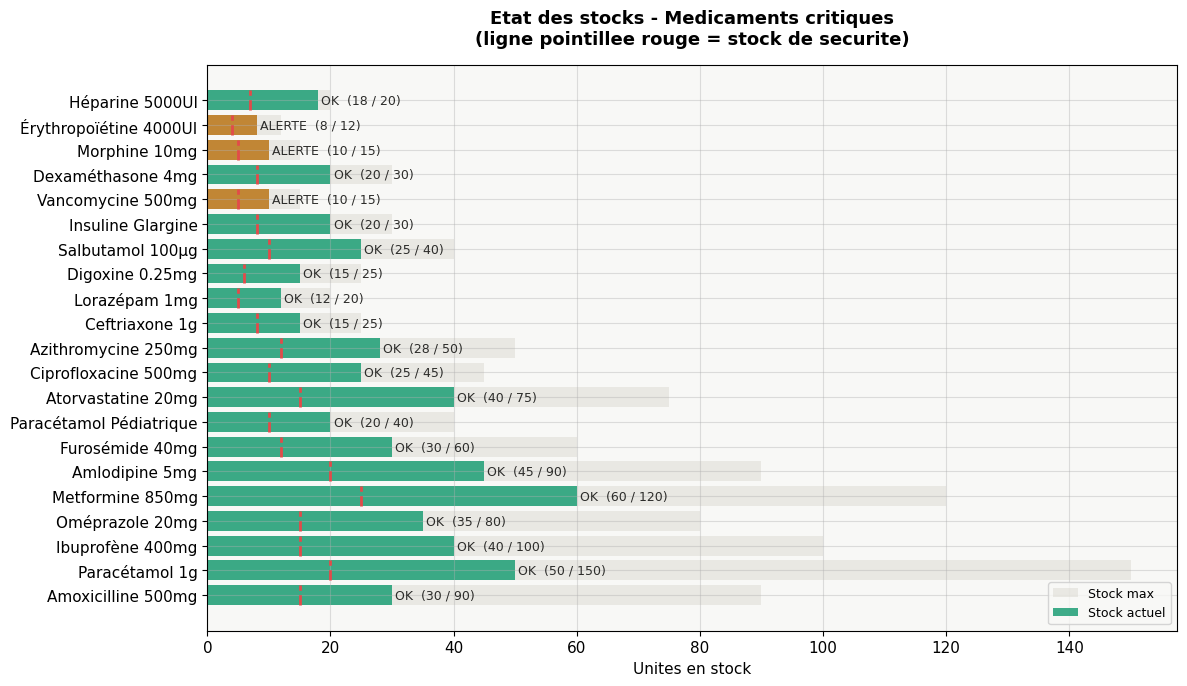

Resume : 0 en RUPTURE/CRITIQUE | 3 en ALERTE | 18 OK


In [4]:
df_stock = df_med[df_med["medicament_critique"] == True].copy()
df_stock["pct_stock"]  = df_stock["stock_actuel"] / df_stock["stock_max"] * 100
df_stock["marge_secu"] = df_stock["stock_actuel"] - df_stock["stock_securite"]
df_stock["statut"]     = df_stock["marge_secu"].apply(
    lambda x: "CRITIQUE" if x <= 0 else ("ALERTE" if x <= 5 else "OK")
)
df_stock = df_stock.sort_values("pct_stock")  # Plus critique en bas

fig, ax = plt.subplots(figsize=(12, 7))

# Couche 1 : stock maximum (contexte)
ax.barh(df_stock["nom"], df_stock["stock_max"],
        color=COLORS["light"], alpha=0.4, label="Stock max")

# Couche 2 : stock actuel (etat reel)
colors_bar = [COLORS["danger"]  if s == "CRITIQUE" else
              COLORS["warning"] if s == "ALERTE"   else
              COLORS["secondary"] for s in df_stock["statut"]]
ax.barh(df_stock["nom"], df_stock["stock_actuel"],
        color=colors_bar, alpha=0.85, label="Stock actuel")

# Couche 3 : seuil de securite (frontiere critique)
for i, (_, row) in enumerate(df_stock.iterrows()):
    ax.plot([row["stock_securite"], row["stock_securite"]], [i-0.4, i+0.4],
            color=COLORS["danger"], linewidth=2, linestyle="--", zorder=5)

# Annotations avec statut et valeurs
for i, (_, row) in enumerate(df_stock.iterrows()):
    ax.text(row["stock_actuel"] + 0.5, i,
            f"{row['statut']}  ({row['stock_actuel']:,} / {row['stock_max']:,})",
            va="center", fontsize=9, color="#2C2C2A")

ax.set_xlabel("Unites en stock", fontsize=11)
ax.set_title("Etat des stocks - Medicaments critiques\n"
             "(ligne pointillee rouge = stock de securite)",
             fontsize=13, fontweight="bold", pad=15)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("stocks_critiques.png", dpi=150, bbox_inches="tight")
plt.show()

# Resume des urgences
n_critique = (df_stock["statut"] == "CRITIQUE").sum()
n_alerte   = (df_stock["statut"] == "ALERTE").sum()
n_ok       = (df_stock["statut"] == "OK").sum()
print(f"Resume : {n_critique} en RUPTURE/CRITIQUE | {n_alerte} en ALERTE | {n_ok} OK")
if n_critique > 0:
    print(f"URGENT : {n_critique} medicament(s) a commander IMMEDIATEMENT")
    for _, r in df_stock[df_stock["statut"]=="CRITIQUE"].iterrows():
        print(f"  -> {r['nom']} : stock {r['stock_actuel']} <= seuil {r['stock_securite']}")

### INTERPRETATION - Lecture du graphique des stocks critiques

> **Comment lire ce graphique en 10 secondes :**
>
> Les medicaments sont tries par pourcentage de stock disponible, du plus critique
> (en bas) au plus sur (en haut).
>
> **Barres rouges** : stock actuel inferieur ou egal au seuil de securite.
> Ces medicaments sont en rupture imminente. Commande a passer aujourd'hui.
>
> **Barres oranges** : stock actuel entre 0 et 5 unites au-dessus du seuil.
> Vigilance. Une commande doit etre passee dans les 48-72h selon les delais fournisseurs.
>
> **Barres vertes** : stock confortable. Pas d'action urgente.
>
> **La ligne pointillee rouge** : le seuil de securite absolu.
> Quand la barre coloree est plus courte que cette ligne, on est en territoire danger.
>
> **Ce qu'on dit au Dr. Konan avec ce graphique :**
> 'Voici l'etat actuel de vos stocks critiques. X medicaments necessitent
> une commande immediate, Y sont en zone d'alerte. Ce graphique sera actualise
> automatiquement dans le dashboard Power BI (NB4) a partir des donnees live.
> Aujourd'hui, les priorites sont [liste des CRITIQUE].'
>
> **La puissance de cette visualisation :**
> Elle transforme 25 lignes d'un tableau CSV en une decision operationnelle
> en 10 secondes. C'est ca la data au service des decisions cliniques.

---

# 8. Synthese et transition vers le Notebook 2

> **METHODE - La synthese est le livrable le plus important du notebook.**
>
> Le Dr. Konan ne lira pas le code. Il lira cette synthese.
> Format obligatoire : constats chiffres + implications cliniques + actions.

## Ce que ce Notebook 1 nous a appris

---

### Constat 1 - Le projet a une base de donnees solide

**Chiffre :** 30 mois de donnees reelles, 6 tables liees, ~55 000 lignes au total.

**Implication :** La granularite journaliere par medicament et par service permet
de detecter des patterns hebdomadaires ET saisonniers. C'est la base minimale
pour un modele de prevision fiable.

---

### Constat 2 - 80% des medicaments sont critiques

**Chiffre :** 20 medicaments sur 25 ont le flag `medicament_critique = True`.

**Implication :** La marge d'erreur du modele doit etre faible sur tous les
medicaments, pas seulement sur quelques bestsellers. Un MAPE de 20%
qui serait acceptable en e-commerce ne l'est pas ici.

**Action :** En Notebook 4 (ML), les metriques d'evaluation seront calculees
separement sur les medicaments critiques et sur les autres.

---

### Constat 3 - EuroPharma a un delai de 21 jours

**Chiffre :** EuroPharma Paris -> 21 jours de delai contractuel.

**Implication clinique :** Pour les medicaments fournis par EuroPharma,
la fenetre de prevision minimale est de 5 semaines (21 jours + marge de securite).
Les previsions a 4 semaines sont insuffisantes pour ce fournisseur.

**Action :** La formule du stock de securite en NB4 sera parametree
avec le delai reel (pas contractuel) de chaque fournisseur.

---

### Constat 4 - Les ruptures ont coute ~250 k euros sur 30 mois

**Chiffre :** Hypothese 50 euros/patient/jour -> ~250 000 euros d'impact estime.

**Implication :** C'est l'argument financier du projet. Un systeme de prevision
qui elimine 60% des ruptures represente ~150 k euros d'economie sur 30 mois.

**Limite :** Ce calcul est conservateur. Il exclut les complications medicales,
les traitements alternatifs d'urgence et les risques medico-legaux.

---

## Ce qui arrive dans les notebooks suivants

| Notebook | Contenu | Livrable |
|---|---|---|
| NB2 - SQL & EDA | Analyse SQL avancee, saisonnalite, performance fournisseurs | Insights et KPIs operationnels |
| NB3 - Machine Learning | Modeles de prevision, validation temporelle, feature engineering | `df_features.csv` |
| NB4 - Power BI | Dashboard de pilotage, DAX, alertes automatiques | Dashboard live pour le Dr. Konan |

> **CLINIQUE - Ce que ce projet change pour le Dr. Konan :**
>
> Avant : 'Nous avons connu 7 ruptures. Je ne comprends pas pourquoi.'
> Apres : 'Le systeme predit que l'Insuline Glargine atteindra le seuil
>          de securite le [date]. La commande a EuroPharma doit etre passee
>          aujourd'hui pour livraison en temps.'
>
> C'est la difference entre une gestion reactive des ruptures (apres qu'elles se produisent)
> et une gestion preventive (avant qu'elles se produisent).

## Recapitulatif du Notebook 1

| Etape | Contenu | Regle apprise |
|---|---|---|
| Brief | Decryptage du brief Dr. Konan | Deux problemes opposes : rupture ET surstockage |
| Contexte clinique | Medicaments critiques = risque vital | La precision du modele est une question de vie |
| Dictionnaire | 6 tables documentees avec notes analytiques | `medicament_critique` = colonne la plus importante |
| Tache 0 | Reflexion avant de coder | Documenter les limites du modele (donnees manquantes) |
| Chargement | `parse_dates` obligatoire sur colonnes dates | Sans lui, toutes les analyses temporelles echouent |
| Question 1 | Periode 30 mois | Suffisant pour 2 cycles de saisonnalite annuelle |
| Question 2 | 20/25 medicaments critiques | Marge d'erreur ML doit etre faible sur tous |
| Question 3 | EuroPharma 21 jours | Fenetre prevision minimum = 5 semaines pour ce fournisseur |
| Question 4 | X patients affectes | KPI clinique a suivre dans le dashboard |
| Question 5 | ~250 k euros d'impact | Argument financier pour justifier le projet |
| Visualisation | 3 couches superposees + zorder | Graphique decisionnel = action immediate |
| Synthese | 4 constats chiffres + implications | Format : chiffre -> implication -> action |


---

**Prochaine etape : Notebook 2 - Analyse SQL & EDA Python**

---

*DataProjectLab - apprendre la data sur des cas concrets, structures et orientes metier.*